# 🧬 Principal Component Analysis (PCA): The Masterclass

Welcome to the deepest dive into PCA. In bioinformatics, you will often find yourself staring at **20,000 genes** and asking: *"How do I visualize this? How do I find the cancer groups without labels?"*

PCA is the ultimate dimensionality reduction technique. You learned Linear Algebra from **3Blue1Brown** and PCA from **StatQuest**. 
Now, we are going to combine them directly in Python: **The Deep Math + Visualizations**.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="darkgrid")
print("Libraries loaded. Ready for PCA!")

Libraries loaded. Ready for PCA!


---
## 📐 Step 1: The Raw Biology Data & Centering
Let's imagine we are tracking exactly 2 numerical features for 100 varying cells: 
- **Gene A Expression** (X-axis)
- **Gene B Expression** (Y-axis)

These genes are correlated (when A goes up, B goes up).

**The Math:**
The absolute first rule of PCA is to **Center the Data** so the origin (0,0) is exactly in the middle of our cell cloud.
$$ X_{centered} = X - \mu $$

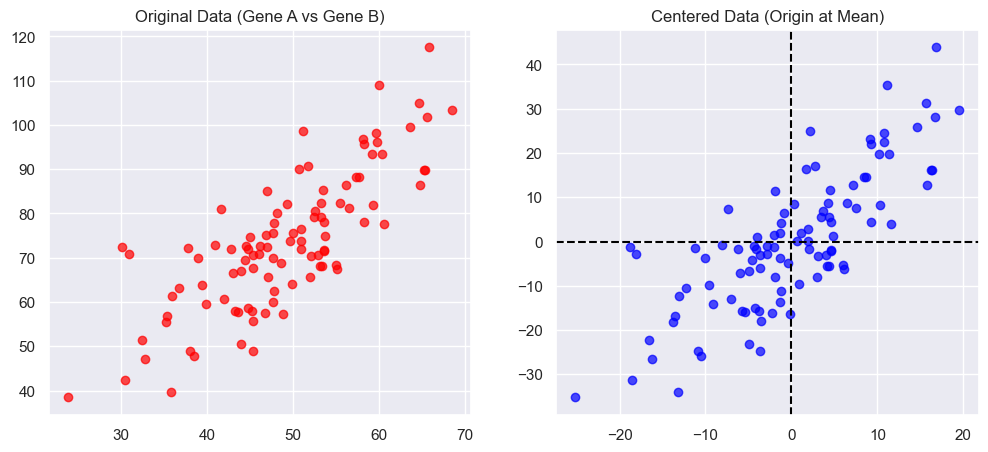

In [3]:
# 1. Create a synthetic correlated dataset of 100 cells
np.random.seed(42)
gene_A = np.random.normal(50, 10, 100) # Mean 50, Std 10
gene_B = gene_A * 1.5 + np.random.normal(0, 10, 100) # Correlated with A

# Combine into matrix X
X = np.column_stack((gene_A, gene_B))

# Mathematically Center the Data
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], alpha=0.7, color='red')
plt.title("Original Data (Gene A vs Gene B)")

plt.subplot(1, 2, 2)
plt.scatter(X_centered[:,0], X_centered[:,1], alpha=0.7, color='blue')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title("Centered Data (Origin at Mean)")
plt.show()

---
## 📊 Step 2: The Covariance Matrix ($\Sigma$)
We need to know mathematically how Gene A and Gene B vary together. 

**Covariance** measures if variables increase together. If Gene A goes up, does Gene B go up? 
The formula for the Covariance Matrix represents:
$$ \Sigma = \frac{1}{n-1} X_{centered}^T X_{centered} $$

If you view this matrix, the diagonal shows the variance of each gene, and the off-diagonals show how they co-vary.

In [4]:
# Calculate Covariance Matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix:")
print(cov_matrix)

# You will see top-left is Gene A's variance.
# Bottom-right is Gene B's variance.
# The other two corners are the massive covariance between them!

Covariance Matrix:
[[ 82.47698936 111.90006476]
 [111.90006476 241.07541792]]


---
## ⚡ Step 3: Eigenvectors & Eigenvalues (Linear Algebra Magic!)
This is straight out of the **3Blue1Brown** essence of Linear Algebra.

We need to find the mathematically distinct "directions" where the data is spread out the most.
$$ \Sigma \vec{v} = \lambda \vec{v} $$

Where:
1. **$\vec{v}$ (Eigenvector):** The physical arrow (direction of the spread, i.e., Principal Component).
2. **$\lambda$ (Eigenvalue):** The physical strength (how much variance/information is captured in that direction).

Let's extract them from the Covariance Matrix and literally draw them.

Eigenvalues (Information retained): [ 24.62668713 298.92572015]
Eigenvectors (Directions):
 [[-0.8883117  -0.45924103]
 [ 0.45924103 -0.8883117 ]]


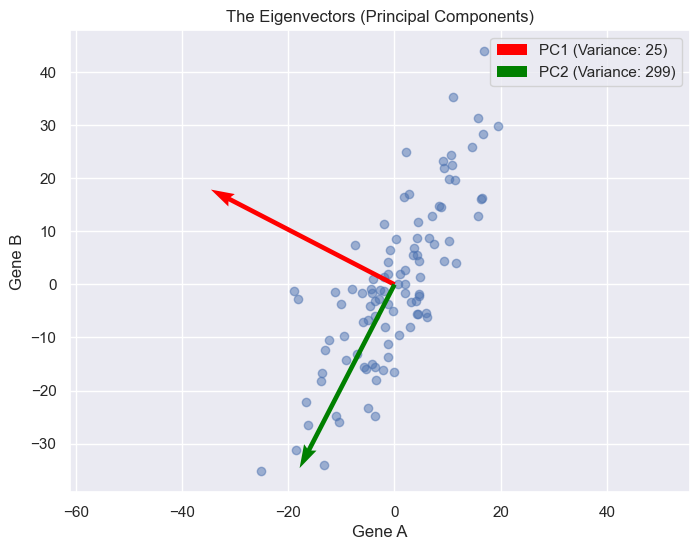

In [5]:
# Compute Eigenvalues & Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues (Information retained):", eigenvalues)
print("Eigenvectors (Directions):\n", eigenvectors)

# Let's visualize the arrows!
plt.figure(figsize=(8, 6))
plt.scatter(X_centered[:,0], X_centered[:,1], alpha=0.5)

# Arrow 1 (Principal Component 1)
plt.quiver(0, 0, eigenvectors[0, 0], eigenvectors[1, 0], 
           color='red', scale=3, label=f'PC1 (Variance: {eigenvalues[0]:.0f})')

# Arrow 2 (Principal Component 2)
plt.quiver(0, 0, eigenvectors[0, 1], eigenvectors[1, 1], 
           color='green', scale=3, label=f'PC2 (Variance: {eigenvalues[1]:.0f})')

plt.title("The Eigenvectors (Principal Components)")
plt.xlabel("Gene A")
plt.ylabel("Gene B")
plt.legend()
plt.axis('equal')
plt.show()

# Notice how the Red arrow spans across the massive shape of the data.
# It captures the most variance!

---
## 🤏 Step 4: Crushing Dimensions (Projection)
Since PC1 (the red arrow) captures almost all the variance, keeping PC2 (the green arrow) is mostly useless. We can compress our 2D biological data into **pure 1D math** by dropping PC2 entirely!

$$ X_{pca} = X_{centered} \cdot \text{Eigenvector}_{1} $$

We are literally taking the dot product of the data and the top vector to fold the graph onto the single line.

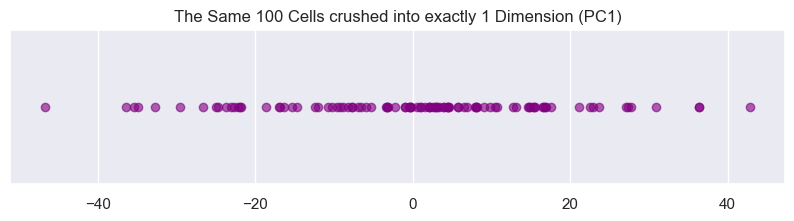

In [6]:
# Sort the eigenvectors by highest eigenvalue
sorted_indices = np.argsort(eigenvalues)[::-1]
top_vector = eigenvectors[:, sorted_indices[0]] # Just grab PC1

# Project 2D data onto the 1D Principal Component vector!
# 100x2 matrix multiplied by 2x1 vector = 100x1 matrix (1D!)
X_1D = np.dot(X_centered, top_vector)

plt.figure(figsize=(10, 2))
plt.scatter(X_1D, np.zeros_like(X_1D), alpha=0.6, color="purple")
plt.title("The Same 100 Cells crushed into exactly 1 Dimension (PC1)")
plt.yticks([])
plt.show()

---
## 🏥 Step 5: How we do it in reality (30 Features to 2D)
Nobody codes Eigenvectors by hand in production. We use `scikit-learn`.

Let's load the **Breast Cancer Dataset (30 features per patient)**. It is impossible for the human brain to visualize a 30-Dimensional graph. So we will use PCA to instantly crush it down to 2 Dimensions.

> ⚠️ **CRITICAL WARNING STATQUEST TAUGHT YOU:** You **MUST** run `StandardScaler` before PCA! PCA searches for maximum variance. If a tumor size is measured in `0.05` and a white blood cell count is measured in `15,000`, PCA will ignore the tumor completely just because the tumor units are tiny. Scaling fixes this.

Original Shape: (569, 30) (30 Dimensions!)
New Shape: (569, 2) (2 Dimensions!)
By keeping only 2 components, we preserved 63.24% of all 30-D biological variance!


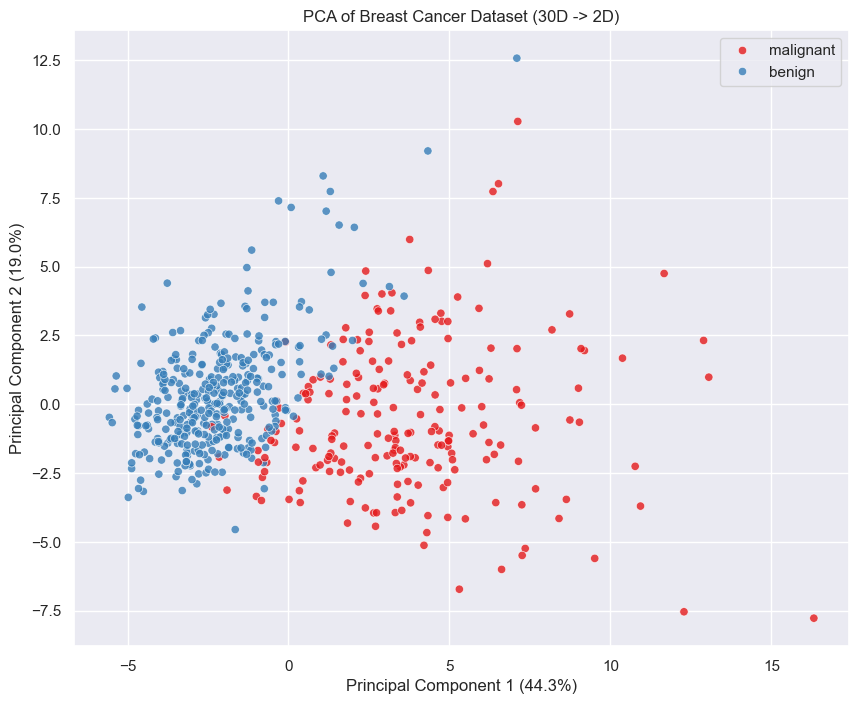

In [8]:
# 1. Load the 30-Dimension Biology Data
cancer = load_breast_cancer()
X_cancer = cancer.data
y_target = cancer.target

print(f"Original Shape: {X_cancer.shape} (30 Dimensions!)")

# 2. CRITICAL: Standard Scale it!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

# 3. Run PCA and ask for exactly 2 Dimensions back
pca_engine = PCA(n_components=2)
X_pca_cancer = pca_engine.fit_transform(X_scaled)

print(f"New Shape: {X_pca_cancer.shape} (2 Dimensions!)")

# 4. View how much total biology data we retained
variance_retained = np.sum(pca_engine.explained_variance_ratio_) * 100
print(f"By keeping only 2 components, we preserved {variance_retained:.2f}% of all 30-D biological variance!")

# 5. Visualize the hidden clusters!
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca_cancer[:,0], y=X_pca_cancer[:,1], hue=cancer.target_names[y_target], palette='Set1', alpha=0.8)
plt.title("PCA of Breast Cancer Dataset (30D -> 2D)")
plt.xlabel(f"Principal Component 1 ({pca_engine.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_engine.explained_variance_ratio_[1]*100:.1f}%)")
plt.show()

### 🎉 Conclusion
Look at the graph above. Without a single Neural Network or SVM involved, simply by finding the massive Eigenvectors of the Covariance Matrix, **the biology naturally split itself apart**. 

Malignant cells are clumped on the left, Benign cells on the right.
If you were to train your `Random Forest` or `SVM` on this new 2D `X_pca_cancer` instead of the 30D array, the SVM would run instantly and still be extremely accurate. 

Welcome to Unsupervised Learning.